# Linear Regression

This notebook gives an overview of linear and multiple regression. It covers theoretical background — including assumptions, pitfalls, and advanced diagnostics — and demonstrates practical examples using Python. Topics include model formulation, data inspection, exploratory analysis, transformation, model estimation, diagnostics, model selection, and prediction. Advanced sections cover regularized regression, partial regression plots, sensitivity analysis via bootstrapping, Bayesian regression using PyMC, and more.

# What is Linear Regression?

Linear regression relates a quantitative response $y$ to one or more predictors $X$ via a linear‐in‐parameters model
$$y_i = \beta_0 + \beta_1x_{i1}+\dots+\beta_Kx_{iK}+\varepsilon_i,$$
where the coefficients $\beta$ capture systematic effects and the error $\varepsilon$ absorbs random noise and omitted factors.  
Ordinary Least Squares (OLS) chooses $\hat\beta$ to minimise the sum of squared residuals, $\sum_i (y_i - X_i\hat\beta)^2$.

## Core OLS Assumptions
1. **Linearity in parameters** $\;E[y\mid X]=X\beta$.  
2. **Strict exogeneity** $\;E[\varepsilon\mid X]=0$.  
3. **Full rank / no perfect multicollinearity** $\;\operatorname{rank}(X)=K+1$.  
4. **Homoscedastic, uncorrelated errors** $\;\operatorname{Var}(\varepsilon\mid X)=\sigma^{2}I$.  

With these, $\hat\beta=(X^{\mathsf T}X)^{-1}X^{\mathsf T}y$ is unbiased, efficient (the **Best Linear Unbiased Estimator**, BLUE) and $\sqrt n\,(\hat\beta-\beta)\;\xrightarrow{d}\;N\bigl(0,\,\sigma^{2}(X^{\mathsf T}X)^{-1}\bigr)$ is asymptotically normal—enabling confidence intervals, $t$‑tests and prediction.

## Key OLS estimator properties
- **Existence:** The predictor matrix $X$ must be full rank so that $(X^T X)^{-1}$ exists.
- **Unbiasedness:** $E(\hat{\beta}) = \beta$ provided that $E(\epsilon)=0$.
- **Consistency:** As the sample size $n \to \infty$, $\hat{\beta}$ converges to $\beta$.
- **Efficiency (BLUE):** Under the Gauss–Markov conditions, OLS is the best linear unbiased estimator.
- **Distributional Properties:** If $\epsilon \sim N(0, \sigma^2 I)$, then $\hat{\beta} \sim N(\beta, \sigma^2 (X^T X)^{-1})$, which is used for inference via t‑tests and F‑tests.

Robust methods or bootstrapping can be employed if these assumptions are approximately met.

### Finite‑Sample Properties of OLS

Although the OLS estimator is given by:

$$\hat{\beta} = (X^T X)^{-1}X^T y,$$

its sampling distribution in finite samples may differ from its large-sample behavior.

For the classical model
$$y = X\beta + \varepsilon, \qquad \varepsilon \mid X \sim \mathcal N\bigl(0,\,\sigma^{2} I_n\bigr),$$
with $\operatorname{rank}(X)=K+1$:

**Proposition 1.1 (exact results)**  
1. **Unbiasedness:** $E\,[\hat\beta\mid X] = \beta$.  
2. **Conditional variance:** $\operatorname{Var}(\hat\beta\mid X) = \sigma^{2}\,(X^{\mathsf T}X)^{-1}$.  
3. **Gauss–Markov:** $\hat\beta$ is BLUE; for any other linear unbiased $\tilde\beta$,
   $$\operatorname{Var}(\tilde\beta\mid X) - \operatorname{Var}(\hat\beta\mid X) \text{ is psd}.$$
4. **Orthogonality:** $\operatorname{Cov}\bigl(\hat\beta,\,e\mid X\bigr)=0$, where $e=y-X\hat\beta$.

**Proposition 1.2 (unbiased $\sigma^{2}$ estimator)**  
$$s^{2}=\frac{e^{\mathsf T}e}{n-K-1}$$
is unbiased for $\sigma^{2}$, and  
$$\frac{(n-K-1)\,s^{2}}{\sigma^{2}} \sim \chi^{2}_{\,n-K-1}.$$

Hence exact $t$‑ and $F$‑tests are available in finite samples.

<IPython.core.display.Math object>

Empirical Var(b1) = 0.0463
Avg theoretical Var(b1|X) = 0.0458


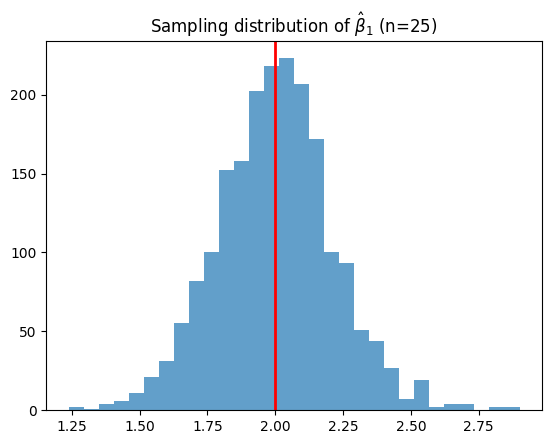

In [1]:
# Monte‑Carlo check of finite‑sample unbiasedness and variance formula
import numpy as np, statsmodels.api as sm, matplotlib.pyplot as plt
from IPython.display import Math, display

np.random.seed(0)
n = 25                # small sample size
sim = 2000            # number of replications
beta_true = np.array([1.0, 2.0])
sigma = 1.0
b1 = []
theor_var = []
for _ in range(sim):
    X = np.column_stack((np.ones(n), np.random.normal(size=n)))
    y = X @ beta_true + np.random.normal(scale=sigma, size=n)
    mod = sm.OLS(y, X).fit()
    b1.append(mod.params[1])
    theor_var.append(sigma**2 * np.linalg.inv(X.T @ X)[1, 1])

b1 = np.array(b1)
display(Math(fr"Mean(\hat{{\beta}}_1)= {b1.mean():.4f}  (\text{{true }}\beta_1={beta_true[1]})"))
print(f"Empirical Var(b1) = {b1.var(ddof=1):.4f}")
print(f"Avg theoretical Var(b1|X) = {np.mean(theor_var):.4f}")

plt.hist(b1, bins=30, alpha=0.7)
plt.axvline(beta_true[1], color='red', lw=2)
plt.title("Sampling distribution of $\\hat{\\beta}_1$ (n=25)")
plt.show()

### Asymptotic Properties of OLS

As the sample size increases, the OLS estimator exhibits the following asymptotic behavior:

$$\sqrt{n}(\hat{\beta} - \beta) \xrightarrow{d} N(0, \sigma^2 (X^T X)^{-1}).$$

This result justifies using normal-based inference in large samples.

## Practical Pitfalls and Mitigations

Linear regression is a powerful tool, but its simplicity entails potential pitfalls if the underlying assumptions are violated. Here are some common issues and strategies:

1. **Non‑linearity**  

   • *Check:* scatter / residual plots

   • *Fix:* transformations (e.g., polynomial, logarithmic), interaction terms.
2. **Heteroscedasticity**  

   • *Check:* residuals‑vs‑fitted, Breusch–Pagan test

   • *Fix:* robust standard errors or weighted least squares.
3. **Non‑normal errors**  

   • *Check:* Q–Q plot, Jarque–Bera test

   • *Fix:* bootstrap, robust M‑estimators.
4. **Autocorrelation**  

   • *Check:* Durbin–Watson test, residual‑lag plot

   • *Fix:* HAC/clustered SEs; for time series data, include lagged predictors or use ARIMA models.
5. **Multicollinearity**  

   • *Check:* VIF, condition number, and eigenvalue analysis

   • *Fix:* drop/combine predictors, centre/scale, ridge/Lasso, use regularization if needed.
6. **Outliers & influence**  

   • *Check:* studentised residuals, Cook’s distance, or DFFITS

   • *Fix:* robust regression models, verify/remove outliers.
7. **Over‑/under‑fitting**  

   • *Check:* cross‑validation, AIC/BIC

   • *Fix:* stepwise regression or penalised models.
8. **Endogeneity**  

   • *Check:* Ensure predictors are exogenous, i.e. uncorrelated with the error term (theory, omission tests)

   • *Fix:* Instrumental Variables (IV) regression, two‑stage least squares.

Linear regression is primarily designed for cross-sectional data. When using it with time series data, note the following:

- **Autocorrelation:** Time series data may have correlated errors. A basic strategy is to include lagged predictors (ee the Extensions section for an example), but dedicated models (e.g., ARIMA) are usually more appropriate for forecasting.
- **Extrapolation:** Predictions outside the range of the training data can be unreliable.
- **Structural Breaks:** In long time series, relationships may change over time. Tests like the Chow test can help detect such changes.

For further reading, consult Draper and Smith’s *Applied Regression Analysis* and Montgomery et al.’s *Introduction to Linear Regression Analysis*.

## Step 1: Formulating the Model

Define your research question and specify the dependent (response) and independent (predictor) variables. For example, consider the model:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon
$$. 

Here, $\beta_0$ is the intercept, $\beta_1$ and $\beta_2$ are the coefficients, and $\epsilon$ is the error term.

In [2]:
# Example: Define a simple linear model function
def linear_model(x1, x2, beta0=1.0, beta1=2.0, beta2=3.0):
    return beta0 + beta1 * x1 + beta2 * x2

x1_example = 5
x2_example = 3
y_example = linear_model(x1_example, x2_example)
print(f"Predicted y for x1={x1_example} and x2={x2_example} is {y_example}")

Predicted y for x1=5 and x2=3 is 20.0


## Step 2: Data Inspection and Preparation

Examine your dataset for missing values, outliers, and multicollinearity. Review summary statistics and check for missing data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
n = 100
x1 = np.random.normal(50, 10, n)
x2 = np.random.normal(30, 5, n)
x2 = 0.5 * x1 + np.random.normal(0, 5, n)  # introduce some multicollinearity
epsilon = np.random.normal(0, 3, n)
y = 5 + 2 * x1 + 3 * x2 + epsilon

df = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'y': y
})
df.loc[5, 'x1'] = np.nan  # Introduce a missing value
df.loc[10, 'y'] = df['y'].mean() + 50  # Introduce an outlier

print(df.head())
print("\nSummary statistics:\n", df.describe())
print("\nMissing values per column:\n", df.isnull().sum())

          x1         x2           y
0  67.640523  31.974353  232.284524
1  54.001572  25.803890  195.389207
2  59.787380  35.391988  230.396231
3  72.408932  39.480785  266.219683
4  68.675580  37.538448  256.965652

Summary statistics:
               x1          x2           y
count  99.000000  100.000000  100.000000
mean   50.702836   25.002879  180.937620
std    10.126559    7.226849   39.604559
min    24.470102    7.455326   74.147368
25%    43.934141   19.614772  151.638315
50%    51.216750   24.600620  181.430224
75%    57.450641   29.804827  212.984429
max    72.697546   40.476565  266.219683

Missing values per column:
 x1    1
x2    0
y     0
dtype: int64


### Handling Missing Data

Instead of simply dropping missing values, you can impute them. For example, mean imputation is performed as:

$$x_{\text{imputed}} = \text{mean}(x).$$

In [4]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print(df_imputed.head())
print("\nMissing values per column:\n", df_imputed.isnull().sum())

          x1         x2           y
0  67.640523  31.974353  232.284524
1  54.001572  25.803890  195.389207
2  59.787380  35.391988  230.396231
3  72.408932  39.480785  266.219683
4  68.675580  37.538448  256.965652

Missing values per column:
 x1    0
x2    0
y     0
dtype: int64


## Step 3: Exploratory Data Analysis (EDA) and Visualization

Use scatter plots, heatmaps, and correlation matrices to explore relationships among variables and diagnose potential multicollinearity or nonlinearity.

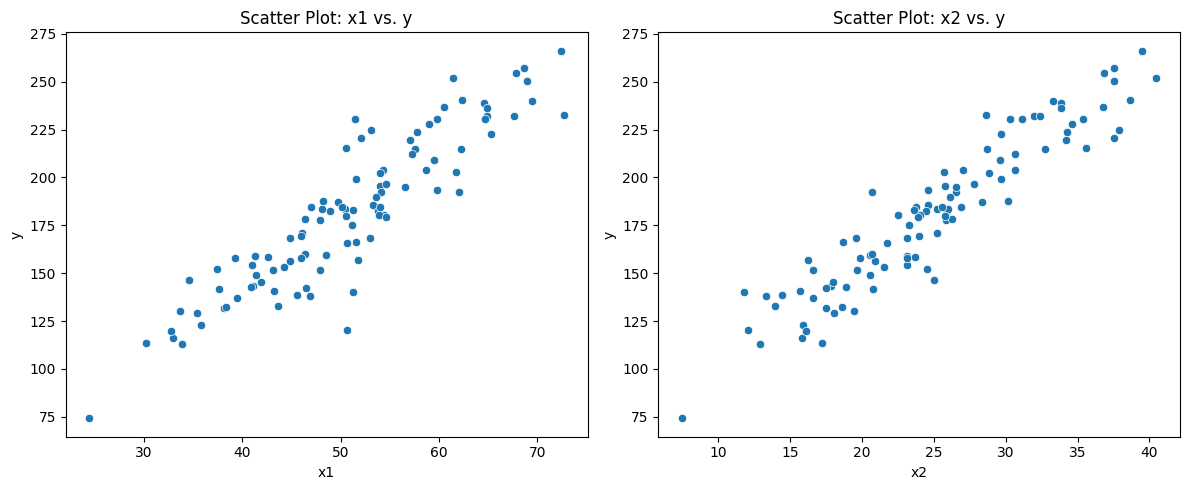

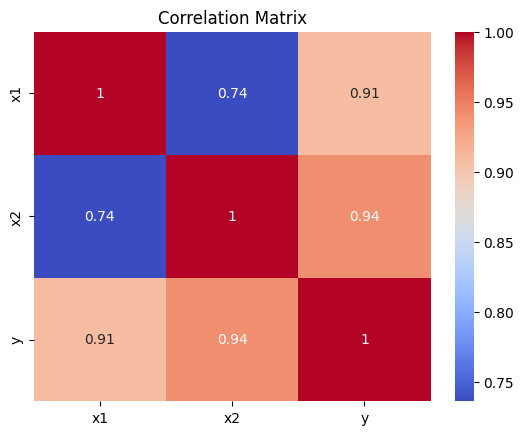

In [5]:
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x='x1', y='y', data=df_imputed, ax=axs[0])
axs[0].set_title('Scatter Plot: x1 vs. y')
sns.scatterplot(x='x2', y='y', data=df_imputed, ax=axs[1])
axs[1].set_title('Scatter Plot: x2 vs. y')
plt.tight_layout()
plt.show()

corr = df_imputed.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Step 4: Data Transformation and Normalization

Apply transformations (e.g., logarithmic or Box-Cox) as needed to stabilize variance and achieve linearity.

Example Formula:

$$x_{\text{log}} = \log(x + c),$$

where $c$ is a constant chosen to ensure the argument is positive.

Skewness of x1: -0.015252269492802645


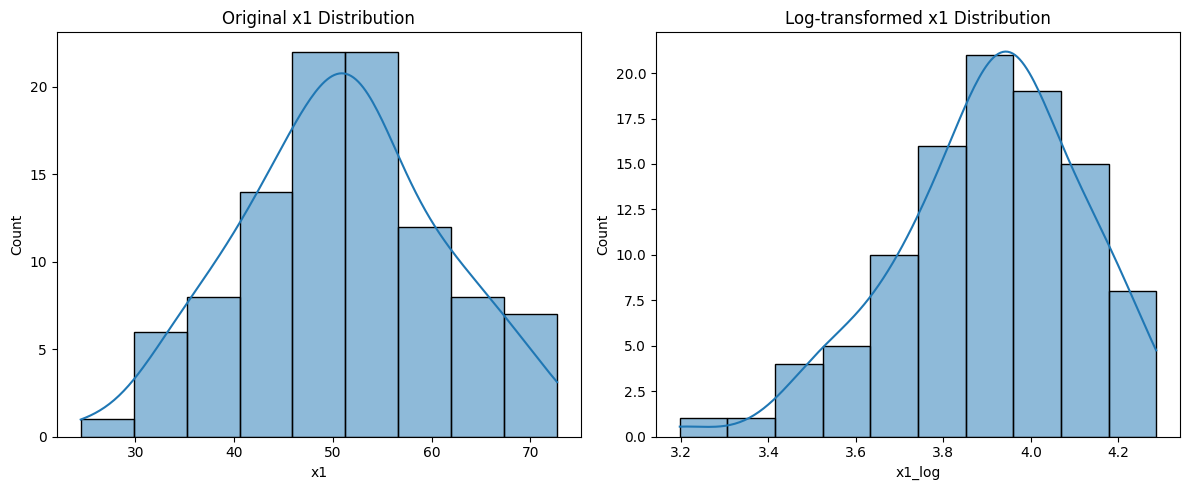

In [6]:
from scipy import stats
print("Skewness of x1:", df_imputed['x1'].skew())
df_imputed['x1_log'] = np.log(df_imputed['x1'].fillna(df_imputed['x1'].mean()))
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_imputed['x1'].dropna(), kde=True, ax=axs[0])
axs[0].set_title('Original x1 Distribution')
sns.histplot(df_imputed['x1_log'], kde=True, ax=axs[1])
axs[1].set_title('Log-transformed x1 Distribution')
plt.tight_layout()
plt.show()

### Note on Centering and Scaling

Centering predictors (subtracting the mean) improves interpretability; the intercept $\beta_0$ then represents $E[y]$ when all predictors are at their average values.

$$x_{centered} = x - \bar{x}.$$

In [7]:
df_centered = df_imputed.copy()
df_centered['x1_centered'] = df_centered['x1'] - df_centered['x1'].mean()
df_centered['x2_centered'] = df_centered['x2'] - df_centered['x2'].mean()
print(df_centered.head())

          x1         x2           y    x1_log  x1_centered  x2_centered
0  67.640523  31.974353  232.284524  4.214207    16.937687     6.971474
1  54.001572  25.803890  195.389207  3.989013     3.298736     0.801011
2  59.787380  35.391988  230.396231  4.090795     9.084544    10.389109
3  72.408932  39.480785  266.219683  4.282330    21.706096    14.477906
4  68.675580  37.538448  256.965652  4.229394    17.972744    12.535569


## Step 5: Model Estimation – Fitting the Regression Model

Fit the OLS model using the cleaned dataset (dropping missing values for simplicity). The OLS estimator is given by:

$$\hat{\beta} = (X^T X)^{-1} X^T y.$$

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

df_clean = df_centered.dropna()
X = df_clean[['x1', 'x2']]
y = df_clean['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add intercept column of 1's to train & test sets
X_tr = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_te = np.column_stack([np.ones(X_test.shape[0]),  X_test])

# Compute β using the normal equation: β = (XᵀX)⁻¹ Xᵀ y
beta = np.linalg.inv(X_tr.T @ X_tr) @ (X_tr.T @ y_train)

# More stable version using least-squares:
beta_stable, *_ = np.linalg.lstsq(X_tr, y_train, rcond=None)

# Intercept and coefficients
intercept    = beta[0]
coefficients = beta[1:]

# Predict on test set
y_pred = X_te @ beta

# Compute R² = 1 – SSR/SST
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2     = 1 - ss_res/ss_tot

print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R-squared on test set:", r2)

Intercept: 6.966048141510782
Coefficients: [1.83029193 3.23824343]
R-squared on test set: 0.9627165631372768


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
score = model.score(X_test, y_test)
print("R-squared on test set:", score)

Intercept: 6.966048141509361
Coefficients: [1.83029193 3.23824343]
R-squared on test set: 0.9627165631372744


### Cross-Validation and Model Selection

After fitting the model, assess its generalizability using cross-validation and compare models using information criteria. The AIC and BIC formulas are:

$$\text{AIC} = -2 \log(\hat{L}) + 2p, \quad \text{BIC} = -2 \log(\hat{L}) + p \log(n),$$

where $\hat{L}$ is the maximized likelihood, $p$ is the number of parameters, and $n$ is the sample size.

In [10]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Average R-squared:", np.mean(cv_scores))

import statsmodels.formula.api as smf
np.random.seed(4)
df_full = pd.DataFrame({
    'y': np.random.normal(100, 10, 100),
    'x1': np.random.normal(50, 5, 100),
    'x2': np.random.normal(30, 3, 100),
    'x3': np.random.normal(20, 2, 100),
    'x4': np.random.normal(10, 1, 100)
})

full_formula = "y ~ x1 + x2 + x3 + x4"
current_formula = full_formula

# Stepwise elimination: remove one predictor at a time if its p-value > 0.05
while True:
    model_temp = smf.ols(current_formula, data=df_full).fit()
    # Exclude the intercept when checking p-values
    pvalues = model_temp.pvalues.drop('Intercept')
    if pvalues.empty:
        break  # No predictors left; stop
    worst_p = pvalues.max()
    if worst_p > 0.05:
        worst_feature = pvalues.idxmax()
        # Get current predictors (strip whitespace)
        predictors = [p.strip() for p in current_formula.split("~")[1].split("+")]
        # Remove the worst predictor if it is in the list, but only if there is more than one predictor left
        if worst_feature in predictors and len(predictors) > 1:
            predictors = [p for p in predictors if p != worst_feature]
            current_formula = "y ~ " + " + ".join(predictors)
        else:
            break  # Stop if removing the predictor would leave an empty formula
    else:
        break

print("Final model formula:", current_formula)
final_model = smf.ols(current_formula, data=df_full).fit()
print(final_model.summary())

Cross-validated R-squared scores: [0.94062203 0.99172405 0.99411255 0.99492969 0.98792849]
Average R-squared: 0.9818633612338896
Final model formula: y ~ x4
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.790
Date:                Sun, 15 Mar 2026   Prob (F-statistic):             0.0981
Time:                        22:02:22   Log-Likelihood:                -368.00
No. Observations:                 100   AIC:                             740.0
Df Residuals:                      98   BIC:                             745.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t

## Step 6: Residual Analysis and Diagnostics

Examine the residuals to assess assumptions such as homoscedasticity, independence, and normality. The residual for each observation is:

$$e = y - \hat{y},$$

and the Mean Squared Error (MSE) is used in computing inference intervals.

### Model Specification Test: Ramsey RESET

The Ramsey RESET test checks for model misspecification by testing whether non-linear combinations of the fitted values can explain the response.

$$\text{RESET test: } H_0:\, \text{the model is correctly specified.}$$

In [11]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

from statsmodels.stats.diagnostic import linear_reset
reset_test = linear_reset(model_sm, power=2, use_f=True)
print("Ramsey RESET test (F-test):", reset_test)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     4798.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.53e-81
Time:                        22:02:22   Log-Likelihood:                -213.78
No. Observations:                  80   AIC:                             433.6
Df Residuals:                      77   BIC:                             440.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9660      2.118      3.289      0.0

### Robust Regression Methods

Outliers can disproportionately affect OLS estimates. Robust regression methods reduce the influence of outliers. Below is an example using statsmodels’ Robust Linear Model (RLM) with the Huber T norm.

In [12]:
import statsmodels.api as sm

# Prepare data for robust regression using the same X_train and y_train
X_train_rlm = sm.add_constant(X_train)

# Fit a Robust Linear Model using the Huber T norm
rlm_model = sm.RLM(y_train, X_train_rlm, M=sm.robust.norms.HuberT()).fit()
print(rlm_model.summary())

# Compare with the OLS model
print("OLS Coefficients:")
print("Intercept: {:.4f}, Coefficients: {}".format(model.intercept_, model.coef_))
print("Robust Regression Coefficients:")
print(rlm_model.params)

                    Robust linear Model Regression Results                    
Dep. Variable:                      y   No. Observations:                   80
Model:                            RLM   Df Residuals:                       77
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 15 Mar 2026                                         
Time:                        22:02:22                                         
No. Iterations:                    16                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.8414      1.796      3.809      0.0

### Weighted Least Squares (WLS)

When heteroskedasticity is present, you can re-weight observations using Weighted Least Squares (WLS). Here, we use the inverse of the absolute residuals as weights.

In [13]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
residuals = y_train - model_sm.predict(X_train_sm)
weights = 1 / np.abs(residuals)
wls_model = sm.WLS(y_train, X_train_sm, weights=weights).fit()
print(wls_model.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            WLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.502e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          1.16e-114
Time:                        22:02:22   Log-Likelihood:                -166.06
No. Observations:                  80   AIC:                             338.1
Df Residuals:                      77   BIC:                             345.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9477      0.780      8.905      0.0

## Step 7: Interpretation and Reporting of Regression Results

Interpret your model using metrics such as $R^2$, adjusted $R^2$, and hypothesis tests for the coefficients. Recall that:

- Each $\beta$ represents the change in the mean response $E[y]$ for a one-unit increase in the corresponding predictor, holding other predictors constant.
- The intercept $\beta_0$ is the estimated $E[y]$ when all predictors are zero. For uncentered data, this may not be meaningful; centering improves interpretability.

For predictions:

- The **confidence interval** for the mean response at $x_{\text{new}}$ is:

$$\hat{y}(x_{\text{new}}) \pm t_{\alpha/2, n-p} \cdot \text{SE}(\hat{y}(x_{\text{new}})),$$

- The **prediction interval** for a new observation is:

$$
\hat{y}(x_{\text{new}}) \pm t_{\alpha/2, n-p} \cdot \sqrt{\text{SE}(\hat{y}(x_{\text{new}}))^2 + \text{MSE}}
$$.

> **Note:** Inference focuses on understanding relationships (e.g., testing $H_0: \beta_k=0$), while prediction aims to forecast new observations (using prediction intervals which are generally wider).

In [14]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     4798.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.53e-81
Time:                        22:02:22   Log-Likelihood:                -213.78
No. Observations:                  80   AIC:                             433.6
Df Residuals:                      77   BIC:                             440.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9660      2.118      3.289      0.0

### Coefficient Interpretation and Effects Plots

Visualize coefficient estimates with 95% confidence intervals to better assess predictor effects.

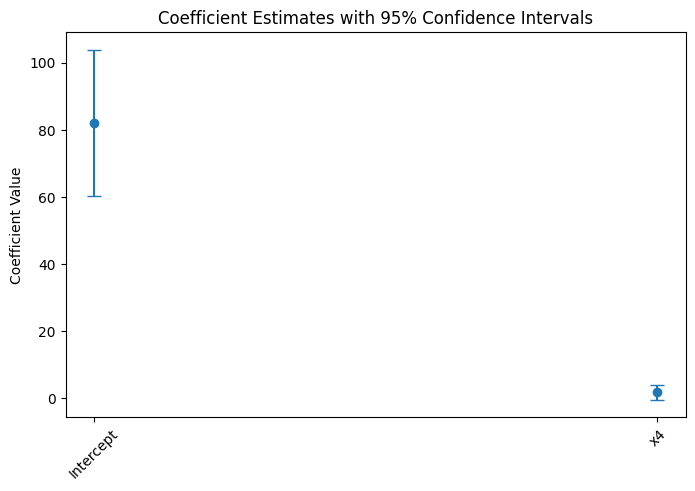

In [15]:
import matplotlib.pyplot as plt
coefs = final_model.params
conf_int = final_model.conf_int()
errors = (conf_int[1] - conf_int[0]) / 2

plt.figure(figsize=(8, 5))
plt.errorbar(coefs.index, coefs.values, yerr=errors, fmt='o', capsize=5)
plt.title('Coefficient Estimates with 95% Confidence Intervals')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()

### Predictions on New Data with Prediction Intervals

Generate predictions for new data along with confidence and prediction intervals.

In [16]:
import statsmodels.api as sm

# Suppose 'final_model' is your model obtained from stepwise elimination.
# And new_data was originally defined only for a subset of variables:
new_data = pd.DataFrame({
    'x1': [55, 48],
    'x2': [29, 31]
})

# Retrieve the predictor names used in final_model (excluding the constant)
pred_names = [name for name in final_model.model.exog_names if name.lower() not in ["const", "intercept"]]
print("Predictor names in the final model:", pred_names)

# For any predictor missing from new_data, fill in with the mean from df_full
new_data_dict = {}
for name in pred_names:
    if name in new_data.columns:
        new_data_dict[name] = new_data[name]
    else:
        # Use the mean of the predictor from df_full
        new_data_dict[name] = [df_full[name].mean()] * new_data.shape[0]

# Create the new_data DataFrame with all required predictors
new_data_full = pd.DataFrame(new_data_dict)

# Add a constant column (statsmodels expects this if the model was fitted with a constant)
new_data_full = sm.add_constant(new_data_full)

# Make predictions using final_model
new_predictions = final_model.get_prediction(new_data_full)
pred_summary_new = new_predictions.summary_frame(alpha=0.05)
print(pred_summary_new)

Predictor names in the final model: ['x4']
         mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  100.352736  0.969094        98.4296     102.275871     81.025465   
1  100.352736  0.969094        98.4296     102.275871     81.025465   

   obs_ci_upper  
0    119.680006  
1    119.680006  


### Partial Regression (Added Variable) Plots

Use partial regression plots to visualize the unique contribution of each predictor after adjusting for the effects of other predictors.

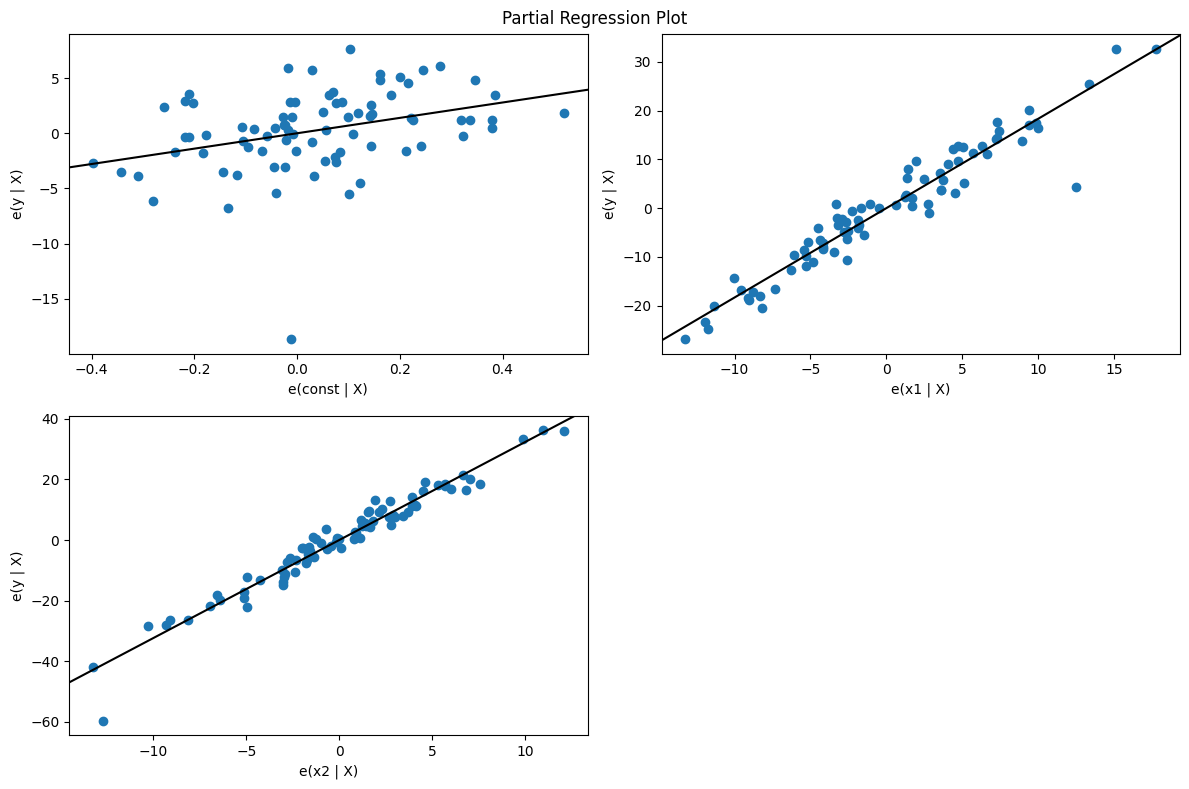

In [17]:
from statsmodels.graphics.regressionplots import plot_partregress_grid
fig = plt.figure(figsize=(12, 8))
plot_partregress_grid(model_sm, fig=fig)
plt.show()

### General Linear Hypothesis Testing

Test whether a subset of predictors significantly contributes to the model. For example, to test

$$H_0: \beta_2 = 0,$$

compare the full model with a reduced model that excludes $x_2$.

In [18]:
X_reduced = df_clean[['x1']]
X_reduced_sm = sm.add_constant(X_reduced)
reduced_model = sm.OLS(y, X_reduced_sm).fit()
f_test = model_sm.compare_f_test(reduced_model)
print(f"F-test statistic: {f_test[0]:.4f}")
print(f"p-value: {f_test[1]:.4f}")
print(f"Degrees of freedom difference: {int(f_test[2])}")

F-test statistic: 98.1347
p-value: 0.0000
Degrees of freedom difference: 21


### Simulation of the OLS Sampling Distribution

Bootstrap simulation illustrates the sampling variability of the OLS estimates.

Bootstrap estimates for coefficients (mean): [5.83417058 1.85041529 3.25246618]
Bootstrap estimates for coefficients (std): [1.49793301 0.07641686 0.13450611]


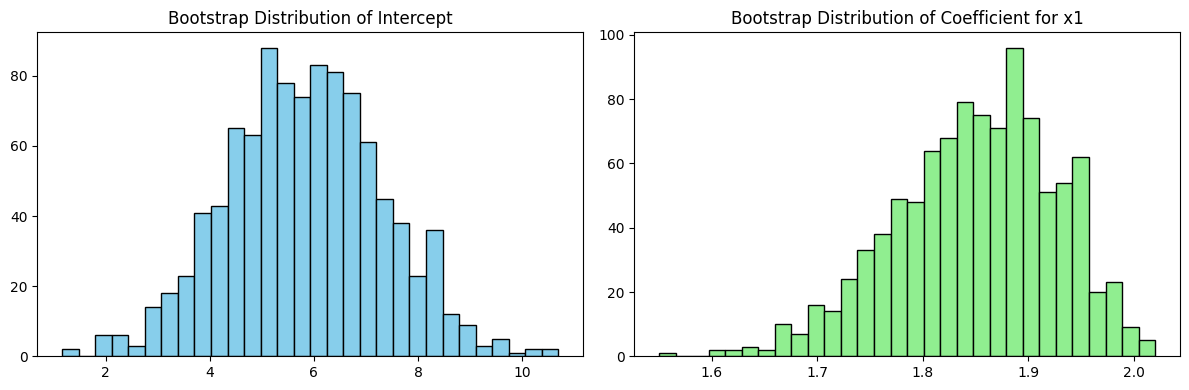

In [19]:
from sklearn.utils import resample
num_simulations = 1000
bootstrap_coefs = []
for i in range(num_simulations):
    sample_df = df_clean.sample(frac=1, replace=True, random_state=i)
    X_sample = sample_df[['x1', 'x2']]
    y_sample = sample_df['y']
    X_sample_sm = sm.add_constant(X_sample)
    model_sample = sm.OLS(y_sample, X_sample_sm).fit()
    bootstrap_coefs.append(model_sample.params.values)

bootstrap_coefs = np.array(bootstrap_coefs)
print("Bootstrap estimates for coefficients (mean):", np.mean(bootstrap_coefs, axis=0))
print("Bootstrap estimates for coefficients (std):", np.std(bootstrap_coefs, axis=0))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(bootstrap_coefs[:, 0], bins=30, color='skyblue', edgecolor='black')
plt.title('Bootstrap Distribution of Intercept')
plt.subplot(1, 2, 2)
plt.hist(bootstrap_coefs[:, 1], bins=30, color='lightgreen', edgecolor='black')
plt.title('Bootstrap Distribution of Coefficient for x1')
plt.tight_layout()
plt.show()

## Extensions to Linear Regression

This subsection demonstrates a variety of extensions to the basic linear regression model, each addressing different practical challenges.

### 1. Instrumental Variables (Two-Stage Least Squares)

**What:** Consistent estimation when a predictor is endogenous by using an instrument $Z$ uncorrelated with the error term.<br>
**When:** The predictor $X$ is correlated with $\varepsilon$ (omitted variables, measurement error, or reverse causality).<br>
**How:**
1. **First stage:** Regress $X$ on $Z$ to get $\hat X$.
2. **Second stage:** Regress $Y$ on $\hat X$ using OLS.

**Theory:** 2SLS yields a consistent estimator under the relevance ($\mathrm{Cov}(Z,X)\neq0$) and exclusion ($\mathrm{Cov}(Z,\varepsilon)=0$) conditions.

In [20]:
import numpy as np
import statsmodels.api as sm

np.random.seed(0)
n = 200

# Instrument
Z = np.random.normal(size=n)

# Endogenous regressor
X = 0.8*Z + np.random.normal(size=n)

# Outcome
Y = 2.5*X + np.random.normal(size=n)

# — First stage: regress X on Z — #
Z1 = sm.add_constant(Z)            # [1, Z]
first_stage = sm.OLS(X, Z1).fit()
X_hat = first_stage.predict(Z1)    # fitted values of X

# — Second stage: regress Y on predicted X — #
X2 = sm.add_constant(X_hat)        # [1, X̂]
second_stage = sm.OLS(Y, X2).fit()
print(second_stage.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     123.8
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.21e-22
Time:                        22:02:23   Log-Likelihood:                -485.00
No. Observations:                 200   AIC:                             974.0
Df Residuals:                     198   BIC:                             980.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1125      0.195     -0.577      0.5

### 2. Quantile Regression

**What:** Models conditional quantiles (e.g. median) instead of the mean.<br>
**When:** Residuals are heteroscedastic or you care about tails (e.g. 10th or 90th percentile).<br>
**How:** Solves a linear programming problem minimizing asymmetrically weighted absolute errors.<br>
**Theory:** Provides estimates $\hat\beta_{\tau}$ such that $P(Y \le X\hat\beta_{\tau}\mid X)=\tau$.

In [21]:
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg

np.random.seed(1)
n = 300
X = np.random.uniform(0, 10, size=(n, 1))
eps = np.random.normal(scale=1 + X.flatten(), size=n)
Y = 1.5 + 0.7 * X.flatten() + eps

X1 = sm.add_constant(X)
model_q50 = QuantReg(Y, X1).fit(q=0.5, max_iter=5000)
model_q90 = QuantReg(Y, X1).fit(q=0.9, max_iter=5000)
print('Median fit:', model_q50.params)
print('90th pct fit:', model_q90.params)

Median fit: [1.83416984 0.6611631 ]
90th pct fit: [3.48154354 1.75517764]


### 3. Mixed-Effects (Hierarchical) Linear Models

**What:** Incorporates both fixed effects and random effects to handle grouped data.<br>
**When:** Data are clustered (e.g. students within schools, repeated measures).<br>
**How:** Models $Y=X\beta + Zb + \varepsilon$, with random effects $b\sim N(0,\Psi)$.<br>
**Theory:** Estimates fixed coefficients $\beta$ and variance components $\Psi$ via ML/REML.

In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

np.random.seed(2)
n_groups = 20
group = np.repeat(np.arange(n_groups), 15)
X1 = np.random.normal(size=n_groups*15)
beta = [1.0, 2.0]
Z = sm.add_constant(X1)
# Random intercepts by group
u = np.random.normal(scale=1.0, size=n_groups)
Y = beta[0] + beta[1]*X1 + np.take(u, group) + np.random.normal(scale=0.5, size=n_groups*15)

df = pd.DataFrame({'Y': Y, 'X1': X1, 'group': group})
md = MixedLM(df['Y'], sm.add_constant(df['X1']), groups=df['group']).fit()
print(md.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Y        
No. Observations: 300     Method:             REML     
No. Groups:       20      Scale:              0.2529   
Min. group size:  15      Log-Likelihood:     -259.7022
Max. group size:  15      Converged:          Yes      
Mean group size:  15.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
const         0.677    0.193  3.508 0.000  0.299  1.055
X1            1.959    0.028 69.229 0.000  1.904  2.015
Group Var     0.728    0.497                           



### 4. Principal‐Component Regression (PCR) and Partial‐Least‐Squares (PLS)

**What:** Dimension reduction before regression.<br>
**When:** Many predictors or severe multicollinearity.<br>
**How:**
- **PCR:** PCA on $X$, then regress $Y$ on top components.
- **PLS:** Finds components maximizing covariance between $X$ and $Y$.

**Theory:** Reduces variance at cost of bias for better prediction.

In [23]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

np.random.seed(3)
n, p = 200, 10
X = np.random.randn(n, p)
true_coef = np.array([1.5, -2.0] + [0]*(p-2))
Y = X.dot(true_coef) + np.random.normal(scale=1.0, size=n)

Xtr, Xte, ytr, yte = train_test_split(X, Y, test_size=0.3, random_state=0)

# PCR: use first 2 PCs
pca = PCA(n_components=2).fit(Xtr)
Xtr_p = pca.transform(Xtr)
Xte_p = pca.transform(Xte)
lr_pcr = LinearRegression().fit(Xtr_p, ytr)
print('PCR R2:', lr_pcr.score(Xte_p, yte))

# PLS: 2 components
pls = PLSRegression(n_components=2).fit(Xtr, ytr)
print('PLS R2:', pls.score(Xte, yte))

PCR R2: 0.34024936825674046
PLS R2: 0.859446755650688


### 5. Regularized Regression: Ridge, Lasso and Elastic Net

**What:** Penalised OLS adding $\ell_2$ (Ridge), $\ell_1$ (Lasso), or combined (Elastic Net) penalty.<br>
**When:** High‐dimensional or collinear predictors; desire for shrinkage/sparsity.<br>
**How:** Minimises $\|Y-Xβ\|^2 + \lambda (\alpha\|β\|_1 + (1-\alpha)\|β\|_2^2)$.

In [24]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, Y = make_regression(n_samples=300, n_features=20, noise=5.0, random_state=4)
Xtr, Xte, ytr, yte = train_test_split(X, Y, test_size=0.3, random_state=42)

print('Ridge R2:', Ridge(alpha=1.0).fit(Xtr,ytr).score(Xte,yte))
print('Lasso R2:', Lasso(alpha=0.5).fit(Xtr,ytr).score(Xte,yte))
print('ElasticNet R2:', ElasticNet(alpha=0.5, l1_ratio=0.7).fit(Xtr,ytr).score(Xte,yte))

Ridge R2: 0.9994128923448573
Lasso R2: 0.9993807432101336
ElasticNet R2: 0.9682526037544228


### 6. Polynomial Regression

**What:** Extends linear model by including polynomial terms of predictors.<br>
**When:** Relationship between $X$ and $Y$ is nonlinear in a smooth way.<br>
**How:** Transforms features with $[x, x^2, x^3,\dots]$ and applies OLS.

In [25]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(5)
x = np.linspace(0, 5, 100)
y = 1 - 0.5*x + 2*(x**2) - x**3 + np.random.normal(scale=5, size=100)
X = x.reshape(-1,1)

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Coefficients: [ 0.         -1.50068732  2.71062005 -1.11189077]
Intercept: 1.539615264652518


### 7. Time Series Regression with Lagged Predictors

**What:** Includes lagged values of $Y$ and/or $X$ to capture dynamics.<br>
**When:** Serial correlation in residuals or dynamic dependence.<br>
**How:** Create lagged features (e.g. $Y_{t-1},X_{t-1}$) and apply OLS or ARIMAX.

In [26]:
import numpy as np, pandas as pd, statsmodels.api as sm

np.random.seed(6)
n=200
eps = np.random.normal(size=n)
Y = np.zeros(n)
for t in range(1,n):
    Y[t]=0.6*Y[t-1] + 0.3*eps[t-1] + eps[t]
df = pd.DataFrame({'Y': Y})
df['Y_lag1'] = df['Y'].shift(1)
df = df.dropna()
X = sm.add_constant(df['Y_lag1'])
model_ts = sm.OLS(df['Y'], X).fit()
print(model_ts.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     210.1
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           6.93e-33
Time:                        22:02:23   Log-Likelihood:                -281.65
No. Observations:                 199   AIC:                             567.3
Df Residuals:                     197   BIC:                             573.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0032      0.071      0.045      0.9

### 8. Bayesian Linear Regression

**What:** Bayesian inference for linear models, yielding full posterior distributions.<br>
**When:** You want probabilistic uncertainty quantification or have small samples.<br>
**How:** Specify priors for $\beta,\sigma$, and sample from the posterior via MCMC.

The model is:

$$y \sim N(\beta_0 + \beta_1 x_1 + \beta_2 x_2,\, \sigma^2),$$

with priors:

$$\beta_i \sim N(0, 5^2), \quad \sigma \sim \text{Half-Normal}(2).$$

In [27]:
import numpy as np
import pymc as pm

np.random.seed(7)
n=100
X = np.random.normal(size=(n,2))
true_b = np.array([1.0, -2.0])
Y = X.dot(true_b) + np.random.normal(scale=1, size=n)

with pm.Model() as model:
    # Priors
    beta = pm.Normal('beta', mu=0, sigma=5, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=2)
    mu = pm.math.dot(X, beta)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=Y)
    trace = pm.sample(1000, tune=1000, cores=1)

print(pm.summary(trace, var_names=['beta','sigma']))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  0.978  0.095   0.796    1.151      0.002    0.002    3193.0   
beta[1] -2.105  0.088  -2.270   -1.947      0.002    0.002    3018.0   
sigma    0.905  0.067   0.789    1.035      0.001    0.002    2701.0   

         ess_tail  r_hat  
beta[0]    1526.0    1.0  
beta[1]    1557.0    1.0  
sigma      1517.0    1.0  


### 9. Sensitivity Analysis via Bootstrapping

**What:** Evaluates OLS estimator variability by repeatedly resampling the data.<br>
**When:** You need non-parametric confidence intervals or to check stability.<br>
**How:** Resample cases with replacement, refit model many times, and examine the distribution of $\hat\beta$.

In [28]:
import numpy as np
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression

np.random.seed(8)
X = np.random.normal(size=(150,3))
coef_true = np.array([0.5, -1.2, 2.0])
Y = X.dot(coef_true) + np.random.normal(scale=1.0, size=150)

n_boot = 1000
boot_coefs = np.zeros((n_boot, 3))
for i in range(n_boot):
    Xs, Ys = resample(X, Y)
    model = LinearRegression().fit(Xs, Ys)
    boot_coefs[i] = model.coef_

print('Bootstrap 95% CI for beta1:', np.percentile(boot_coefs[:,0],[2.5,97.5]))

Bootstrap 95% CI for beta1: [0.27310617 0.64326152]


### 10. Dummy Variable Regression

**What:**  Incorporate categorical predictors by converting each category into a 0/1 indicator (dummy) variable.<br>
**When:**  You have one or more categorical features (e.g. gender, region, treatment group).<br>
**How:**
1. Use `pandas.get_dummies(..., drop_first=True)` to create $k-1$ dummies for a $k$-level factor (to avoid perfect multicollinearity).
2. Fit an OLS model including these dummies alongside your numeric predictors.

**Theory:**  The intercept represents the baseline category mean, and each dummy’s coefficient is the difference of that category’s mean from the baseline.

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Simulate data
np.random.seed(0)
n = 150
# Categorical with three groups: A, B, C
group = np.random.choice(['A','B','C'], size=n)
# Numeric predictor
x = np.random.normal(0, 1, size=n)
# Assign different intercepts by group
intercepts = {'A': 2.0, 'B': 4.0, 'C': 6.0}
y = np.array([intercepts[g] for g in group]) + 1.5 * x + np.random.normal(scale=1, size=n)

# Build DataFrame and dummies
df = pd.DataFrame({'y': y, 'x': x, 'group': group})
df_dummies = pd.get_dummies(df, columns=['group'], drop_first=True)
# cast all relevant columns to float
for col in ['y','x','group_B','group_C']:
    df_dummies[col] = df_dummies[col].astype(float)

# Prepare design matrix
X = sm.add_constant(df_dummies[['x','group_B','group_C']])
model = sm.OLS(df_dummies['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     217.1
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.33e-53
Time:                        22:02:30   Log-Likelihood:                -214.52
No. Observations:                 150   AIC:                             437.0
Df Residuals:                     146   BIC:                             449.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0490      0.138     14.825      0.0

### 11. Interaction Effects in Linear Regression

**What:**  Allows the effect of one predictor to depend on the level of another by including a product term $X_1\times X_2$.<br>
**When:**  You suspect that the slope for $X_1$ changes with $X_2$ (e.g. treatment effect varies by age).<br>
**How:**
1. Create a new feature `X1 * X2`.
2. Include `X1`, `X2`, and `X1*X2` in the regression.
3. Interpret: the coefficient on `X1` is the effect of `X1` when `X2=0`; the interaction coefficient shows how that effect changes per unit of `X2`.

**Theory:**  Model $y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 + \varepsilon$.  The marginal effect of $X_1$ is $\beta_1 + \beta_3 X_2$.

In [30]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Simulate data with one continuous X1 and one binary X2
np.random.seed(1)
n = 200
x1 = np.random.normal(0, 1, size=n)
x2 = np.random.binomial(1, 0.5, size=n)
# True coefficients
beta0, beta1, beta2, beta3 = 1.0, 2.0, -1.0, 0.5
# Generate y with interaction
y = (beta0
     + beta1 * x1
     + beta2 * x2
     + beta3 * x1 * x2
     + np.random.normal(scale=1, size=n))

# Build DataFrame
df_int = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
# Add interaction term
df_int['x1_x2'] = df_int['x1'] * df_int['x2']

# Fit model
X = sm.add_constant(df_int[['x1','x2','x1_x2']])
model_int = sm.OLS(df_int['y'], X).fit()
print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     269.4
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           2.89e-69
Time:                        22:02:30   Log-Likelihood:                -289.77
No. Observations:                 200   AIC:                             587.5
Df Residuals:                     196   BIC:                             600.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0524      0.105     10.003      0.0

## Summary and Conclusions

This notebook serves as both a tutorial and a practical guide for building, validating, and refining regression models, covering:

- **Theoretical Foundations:** Assumptions, pitfalls, and key formulas (e.g., the OLS estimator, partial $R^2$, and confidence/prediction interval formulas).
- **Data Preparation and EDA:** Handling missing data (with imputation), centering and scaling, transformation, and exploratory analysis.
- **Model Fitting and Diagnostics:** Fitting an OLS model, examining residuals, and applying diagnostic tests (including the Ramsey RESET test, robust standard errors, robust regression methods, and weighted least squares).
- **Interpretation and Inference:** Using t-tests, F-tests, and understanding the difference between inference (understanding relationships) and prediction (forecasting new observations). Each $\beta$ represents the change in $E[y]$ per unit increase in the predictor (holding other variables constant), and centering improves the interpretability of the intercept.
- **Extensions:** Additional examples covering dummy variable regression, interaction terms, polynomial regression, instrumental variables, principal component regression and partial least-squares, quantile regression, regularized regression (Ridge and Lasso), time series regression with lagged predictors, Bayesian regression using PyMC, and sensitivity analysis via bootstrapping.